In [45]:
import pandas as pd

In [46]:
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv("Retail_sales_analysis - Sheet1.csv")

In [48]:
df.head()

,Order_ID,Order_Date,Customer_Name,Gender,Age,City,Region,Product,Category,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Rating,duplicate
0,"1,001",25-06-2025,Unknown,Female,27,Jaipur,North,Mixer,Home,2,"2,800",50,"-2,240","3,982","-6,160",Unknown,4.3,1
1,"1,002",30-03-2025,Neha,Female,42,Delhi,North,Chair,Furniture,3,"4,500",20,"10,800","9,450","1,350",Net Banking,4.9,1
2,"1,003",13-02-2025,Priya,Female,38,Jaipur,North,T-shirt,Fashion,3,"1,200",0,"3,600","2,520","1,080",UPI,4.5,1
3,"1,004",09-04-2025,Priya,Female,47,Bangalore,South,Shoes,Fashion,5,"3,500",0,"17,500","12,250","5,250",Net Banking,3.8,1
4,"1,005",06-03-2025,Sneha,Male,33,Kolkata,East,Headphones,Electronics,2,"2,500",20,"4,000","3,500",500,UPI,3.8,1


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         200 non-null    str    
 1   Order_Date       200 non-null    str    
 2   Customer_Name    200 non-null    str    
 3   Gender           200 non-null    str    
 4   Age              200 non-null    int64  
 5   City             200 non-null    str    
 6   Region           200 non-null    str    
 7   Product          200 non-null    str    
 8   Category         200 non-null    str    
 9   Quantity         200 non-null    int64  
 10  Unit_Price       200 non-null    str    
 11  Discount         200 non-null    int64  
 12  Sales            200 non-null    str    
 13  Cost             200 non-null    str    
 14  Profit           200 non-null    str    
 15  Payment_Method   200 non-null    str    
 16  Customer_Rating  200 non-null    float64
 17  duplicate        200 non-nu

In [50]:
df.describe()

,Age,Quantity,Discount,Customer_Rating,duplicate
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,37.970000,2.995000,10.500000,4.268500,1.010000
std,12.531733,1.512087,8.447294,0.421123,0.099748
min,19.000000,1.000000,0.000000,3.500000,1.000000
25%,27.000000,2.000000,5.000000,3.900000,1.000000
50%,38.000000,3.000000,10.000000,4.300000,1.000000
75%,49.000000,5.000000,15.000000,4.600000,1.000000
max,60.000000,5.000000,50.000000,5.000000,2.000000


In [51]:
df.isnull().sum()

Order_ID           0
Order_Date         0
Customer_Name      0
Gender             0
Age                0
City               0
Region             0
Product            0
Category           0
Quantity           0
Unit_Price         0
Discount           0
Sales              0
Cost               0
Profit             0
Payment_Method     0
Customer_Rating    0
duplicate          0
dtype: int64

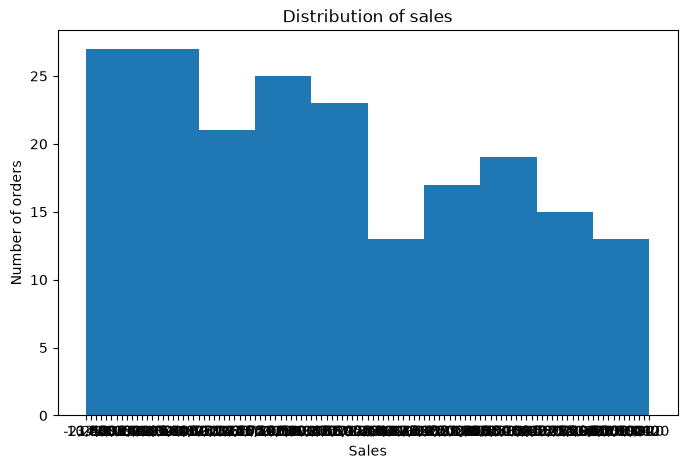

In [52]:
plt.figure(figsize =(8,5))
plt.hist(df['Sales'], bins =10)
plt.title('Distribution of sales')
plt.xlabel('Sales')
plt.ylabel('Number of orders')
plt.show()

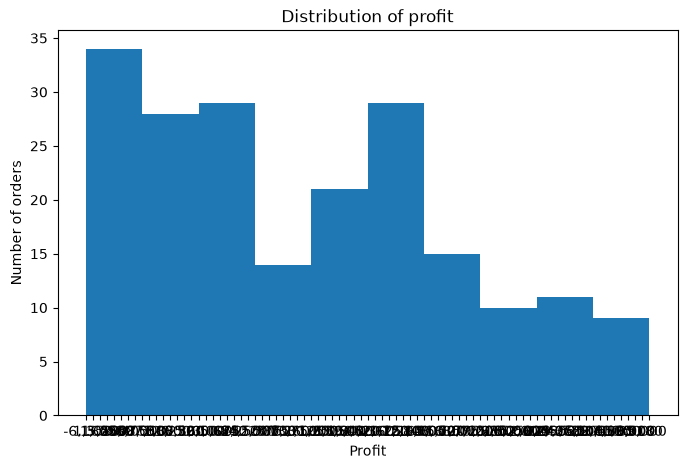

In [53]:
plt.figure(figsize = (8,5))
plt.hist(df['Profit'], bins =10)
plt.title('Distribution of profit')
plt.xlabel('Profit')
plt.ylabel('Number of orders')
plt.show()

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         200 non-null    str    
 1   Order_Date       200 non-null    str    
 2   Customer_Name    200 non-null    str    
 3   Gender           200 non-null    str    
 4   Age              200 non-null    int64  
 5   City             200 non-null    str    
 6   Region           200 non-null    str    
 7   Product          200 non-null    str    
 8   Category         200 non-null    str    
 9   Quantity         200 non-null    int64  
 10  Unit_Price       200 non-null    str    
 11  Discount         200 non-null    int64  
 12  Sales            200 non-null    str    
 13  Cost             200 non-null    str    
 14  Profit           200 non-null    str    
 15  Payment_Method   200 non-null    str    
 16  Customer_Rating  200 non-null    float64
 17  duplicate        200 non-nu

In [55]:
df['Sales'] = df['Sales'].astype(str).str.replace(",","")
df['Sales'] = pd.to_numeric(df['Sales'])

df['Profit'] = df['Sales'].astype(str).str.replace(",","")
df['Profit'] = pd.to_numeric(df['Profit'])

In [56]:
df[['Profit','Sales']].corr()

,Profit,Sales
Profit,1.0,1.0
Sales,1.0,1.0


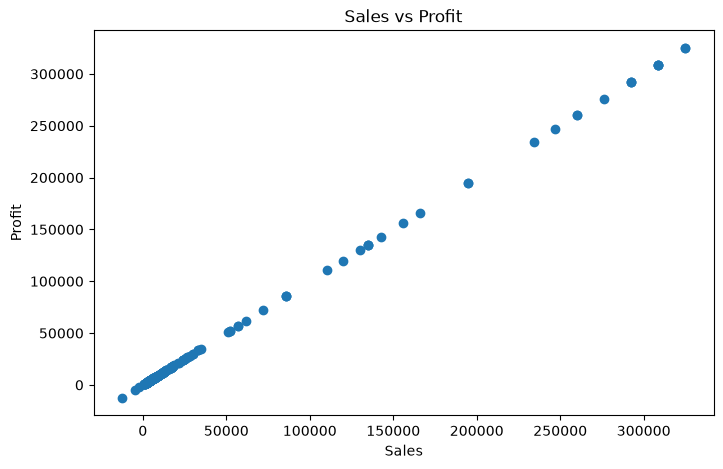

In [57]:
plt.figure(figsize = (8,5))
plt.scatter(df['Sales'], df['Profit'])
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

In [58]:
df['Payment_Method'].value_counts().sort_values(ascending=False)

Payment_Method
Card           54
Net Banking    50
Cash           50
UPI            42
Unknown         4
Name: count, dtype: int64

In [59]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head()

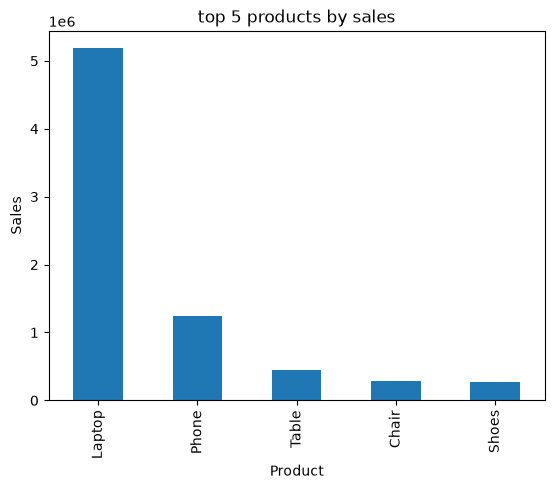

In [60]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head()
top_products.plot(kind ='bar')
plt.title("top 5 products by sales")
plt.xlabel('Product')
plt.ylabel('Sales')
plt.show()


In [61]:
df.groupby('Category')['Profit'].mean().sort_values(ascending=False)

Category
Electronics    97884.328358
Furniture      14506.000000
Home            7781.666667
Fashion         6542.457627
Name: Profit, dtype: float64

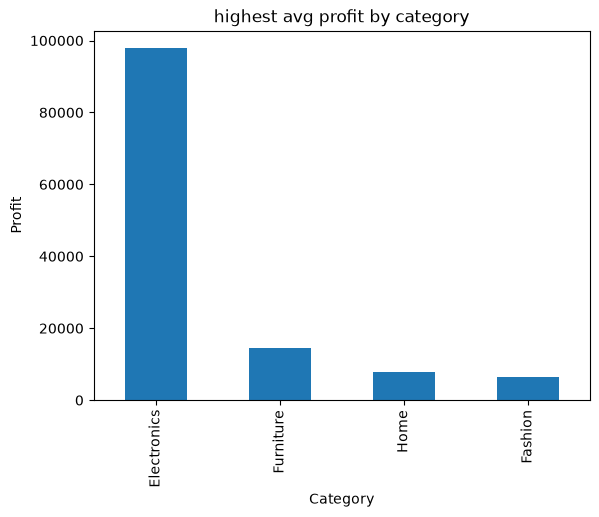

In [62]:
df.groupby('Category')['Profit'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('highest avg profit by category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

In [68]:
df.nlargest(5, 'Sales')

,Order_ID,Order_Date,Customer_Name,Gender,Age,City,Region,Product,Category,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Rating,duplicate
9,"1,010",06-02-2025,Rahul,Male,50,Jaipur,North,Laptop,Electronics,5,"65,000",0,325000,"2,27,500",325000,Cash,3.6,1
87,"1,088",21-03-2025,Vikram,Male,53,Hyderabad,South,Laptop,Electronics,5,"65,000",0,325000,"2,27,500",325000,Cash,4.8,1
12,"1,013",05-01-2025,Neha,Male,37,Mumbai,West,Laptop,Electronics,5,"65,000",5,308750,"2,27,500",308750,Card,3.9,1
107,"1,108",15-01-2025,Sneha,Male,23,Hyderabad,South,Laptop,Electronics,5,"65,000",5,308750,"2,27,500",308750,Card,4.5,1
152,"1,153",12-04-2025,Rahul,Male,55,Chennai,South,Laptop,Electronics,5,"65,000",5,308750,"2,27,500",308750,Net Banking,3.8,1


In [71]:
df.query('Sales > 20000').head()

,Order_ID,Order_Date,Customer_Name,Gender,Age,City,Region,Product,Category,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Rating,duplicate
7,"1,008",26-06-2025,Neha,Female,46,Chennai,South,Table,Furniture,5,"7,000",5,33250,"24,500",33250,UPI,4.9,1
8,"1,009",12-06-2025,Priya,Male,42,Bangalore,South,Laptop,Electronics,3,"65,000",0,195000,"1,36,500",195000,Card,4.0,1
9,"1,010",06-02-2025,Rahul,Male,50,Jaipur,North,Laptop,Electronics,5,"65,000",0,325000,"2,27,500",325000,Cash,3.6,1
12,"1,013",05-01-2025,Neha,Male,37,Mumbai,West,Laptop,Electronics,5,"65,000",5,308750,"2,27,500",308750,Card,3.9,1
21,"1,022",19-05-2025,Riya,Male,54,Delhi,North,Phone,Electronics,1,"30,000",20,24000,"21,000",24000,Cash,3.8,1


In [72]:
df.query('City == "Delhi"')

,Order_ID,Order_Date,Customer_Name,Gender,Age,City,Region,Product,Category,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Rating,duplicate
1,"1,002",30-03-2025,Neha,Female,42,Delhi,North,Chair,Furniture,3,"4,500",20,10800,"9,450",10800,Net Banking,4.9,1
10,"1,011",24-03-2025,Riya,Male,25,Delhi,North,T-shirt,Fashion,1,"1,200",20,960,840,960,Net Banking,3.6,1
15,"1,016",16-03-2025,Sneha,Male,21,Delhi,North,Mixer,Home,5,"2,800",5,13300,"9,800",13300,Cash,4.7,1
18,"1,019",04-01-2025,Rahul,Male,30,Delhi,North,Table,Furniture,2,"7,000",15,11900,"9,800",11900,Cash,3.8,1
21,"1,022",19-05-2025,Riya,Male,54,Delhi,North,Phone,Electronics,1,"30,000",20,24000,"21,000",24000,Cash,3.8,1
33,"1,034",28-02-2025,Aarav,Female,54,Delhi,North,Headphones,Electronics,5,"2,500",0,12500,"8,750",12500,Cash,4.3,1
36,"1,037",18-04-2025,Karan,Female,55,Delhi,North,Chair,Furniture,4,"4,500",5,17100,"12,600",17100,Cash,4.3,1
40,"1,041",09-02-2025,Sneha,Male,25,Delhi,North,T-shirt,Fashion,1,"1,200",5,1140,840,1140,Cash,4.1,1
46,"1,047",25-02-2025,Aman,Female,19,Delhi,North,Phone,Electronics,3,"30,000",20,72000,"63,000",72000,Net Banking,3.9,1
52,"1,053",29-04-2025,Riya,Male,23,Delhi,North,Headphones,Electronics,1,"2,500",20,2000,"1,750",2000,Cash,4.9,1


In [73]:
df.query('Sales > 20000 and Profit > 5000')

,Order_ID,Order_Date,Customer_Name,Gender,Age,City,Region,Product,Category,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Rating,duplicate
7,"1,008",26-06-2025,Neha,Female,46,Chennai,South,Table,Furniture,5,"7,000",5,33250,"24,500",33250,UPI,4.9,1
8,"1,009",12-06-2025,Priya,Male,42,Bangalore,South,Laptop,Electronics,3,"65,000",0,195000,"1,36,500",195000,Card,4.0,1
9,"1,010",06-02-2025,Rahul,Male,50,Jaipur,North,Laptop,Electronics,5,"65,000",0,325000,"2,27,500",325000,Cash,3.6,1
12,"1,013",05-01-2025,Neha,Male,37,Mumbai,West,Laptop,Electronics,5,"65,000",5,308750,"2,27,500",308750,Card,3.9,1
21,"1,022",19-05-2025,Riya,Male,54,Delhi,North,Phone,Electronics,1,"30,000",20,24000,"21,000",24000,Cash,3.8,1
22,"1,023",07-04-2025,Rahul,Male,28,Kolkata,East,Chair,Furniture,5,"4,500",5,21375,"15,750",21375,UPI,3.6,1
27,"1,028",29-05-2025,Priya,Male,30,Bangalore,South,Laptop,Electronics,5,"65,000",20,260000,"2,27,500",260000,UPI,3.9,1
35,"1,036",23-04-2025,Aman,Male,43,Jaipur,North,Phone,Electronics,5,"30,000",10,135000,"1,05,000",135000,UPI,4.1,1
41,"1,042",02-05-2025,Aarav,Female,42,Pune,West,Laptop,Electronics,1,"65,000",20,52000,"45,500",52000,Cash,4.6,1
42,"1,043",03-04-2025,Aarav,Female,28,Hyderabad,South,Laptop,Electronics,2,"65,000",15,110500,"91,000",110500,Cash,4.6,1


In [78]:
df[df['Sales']>20000]

,Order_ID,Order_Date,Customer_Name,Gender,Age,City,Region,Product,Category,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Rating,duplicate
7,"1,008",26-06-2025,Neha,Female,46,Chennai,South,Table,Furniture,5,"7,000",5,33250,"24,500",33250,UPI,4.9,1
8,"1,009",12-06-2025,Priya,Male,42,Bangalore,South,Laptop,Electronics,3,"65,000",0,195000,"1,36,500",195000,Card,4.0,1
9,"1,010",06-02-2025,Rahul,Male,50,Jaipur,North,Laptop,Electronics,5,"65,000",0,325000,"2,27,500",325000,Cash,3.6,1
12,"1,013",05-01-2025,Neha,Male,37,Mumbai,West,Laptop,Electronics,5,"65,000",5,308750,"2,27,500",308750,Card,3.9,1
21,"1,022",19-05-2025,Riya,Male,54,Delhi,North,Phone,Electronics,1,"30,000",20,24000,"21,000",24000,Cash,3.8,1
22,"1,023",07-04-2025,Rahul,Male,28,Kolkata,East,Chair,Furniture,5,"4,500",5,21375,"15,750",21375,UPI,3.6,1
27,"1,028",29-05-2025,Priya,Male,30,Bangalore,South,Laptop,Electronics,5,"65,000",20,260000,"2,27,500",260000,UPI,3.9,1
35,"1,036",23-04-2025,Aman,Male,43,Jaipur,North,Phone,Electronics,5,"30,000",10,135000,"1,05,000",135000,UPI,4.1,1
41,"1,042",02-05-2025,Aarav,Female,42,Pune,West,Laptop,Electronics,1,"65,000",20,52000,"45,500",52000,Cash,4.6,1
42,"1,043",03-04-2025,Aarav,Female,28,Hyderabad,South,Laptop,Electronics,2,"65,000",15,110500,"91,000",110500,Cash,4.6,1


In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.drop_duplicates()

,Order_ID,Order_Date,Customer_Name,Gender,Age,City,Region,Product,Category,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Rating,duplicate
0,"1,001",25-06-2025,Unknown,Female,27,Jaipur,North,Mixer,Home,2,"2,800",50,-2240,"3,982",-2240,Unknown,4.3,1
1,"1,002",30-03-2025,Neha,Female,42,Delhi,North,Chair,Furniture,3,"4,500",20,10800,"9,450",10800,Net Banking,4.9,1
2,"1,003",13-02-2025,Priya,Female,38,Jaipur,North,T-shirt,Fashion,3,"1,200",0,3600,"2,520",3600,UPI,4.5,1
3,"1,004",09-04-2025,Priya,Female,47,Bangalore,South,Shoes,Fashion,5,"3,500",0,17500,"12,250",17500,Net Banking,3.8,1
4,"1,005",06-03-2025,Sneha,Male,33,Kolkata,East,Headphones,Electronics,2,"2,500",20,4000,"3,500",4000,UPI,3.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,"1,196",28-06-2025,Rahul,Male,54,Jaipur,North,Mixer,Home,2,"2,800",10,5040,"3,920",5040,Net Banking,4.1,1
196,"1,197",01-05-2025,Rahul,Male,58,Pune,West,Table,Furniture,3,"7,000",20,16800,"14,700",16800,Card,4.2,1
197,"1,198",18-01-2025,Vikram,Male,34,Delhi,North,Mixer,Home,4,"2,800",20,8960,"7,840",8960,Net Banking,4.4,1
198,"1,199",16-05-2025,Aarav,Female,46,Bangalore,South,T-shirt,Fashion,1,"1,200",15,1020,840,1020,Net Banking,4.3,1
